## 1. Import Libraries and Load Data
Load the necessary data science libraries and the intersection dataset.

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Define the local file path 
file_path = r"C:\Users\Akapl\Desktop\College 4\Applied Data Science\MASTER_INTERSECTIONS_50ft_FINAL.csv"

# Load the dataset
try:
    df = pd.read_csv(file_path)
    print("Data loaded successfully.")
    print(f"Dataset shape: {df.shape}")
except FileNotFoundError:
    print("Error: File not found. Verify the file name and path.")

Data loaded successfully.
Dataset shape: (27253, 12)


## 2. Data Preprocessing
Exclude `CRASH_COUNT_50FT` to prevent data leakage. Isolate the target variable (`HAS_CRASH`) and apply One-Hot Encoding to the categorical `BOROUGH` column.

In [2]:
# Define features to keep based on previous dataset analysis
# Exclude INTERSECTION_ID, X, Y, LocationDescription, HAS_SIGNAL, and CRASH_COUNT_50FT
numeric_features = ['Signalized', 'Stop_Controlled', 'Uncontrolled', 'COMPLAINT_COUNT_50FT']

# Create the Feature Matrix (X)
X_base = df[numeric_features].copy()

# One-hot encode the BOROUGH column to convert it into numeric binary columns
# drop_first=False is kept here to ensure all boroughs are explicitly represented
borough_dummies = pd.get_dummies(df['BOROUGH'], prefix='Borough')
X = pd.concat([X_base, borough_dummies], axis=1)

# Create the Target Vector (y)
y = df['HAS_CRASH']

print(f"Feature matrix shape: {X.shape}")
print(f"Target vector shape: {y.shape}")

Feature matrix shape: (27253, 10)
Target vector shape: (27253,)


## 3. Train-Test Split
Split the data into 80% training and 20% testing sets to evaluate model performance on unseen data.

In [3]:
# Perform the 80/20 split. random_state ensures reproducibility.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training instances: {X_train.shape[0]}")
print(f"Testing instances: {X_test.shape[0]}")

Training instances: 21802
Testing instances: 5451


## 4. Hyperparameter Tuning with GridSearchCV
To optimize the model, I tested different combinations of 'n_estimators', 'max_depth', and 'min_samples_split'. This process ensures the model learns the most robust patterns without overfitting.

In [4]:
## 4. Final Optimized Model Training
# I use the parameters identified during the hyperparameter tuning phase
# to ensure the model captures patterns accurately without overfitting.

final_model = RandomForestClassifier(
    criterion='gini',
    max_depth=10,
    min_samples_split=10,
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

# Fit the final model to the training data
print("Training final optimized model...")
final_model.fit(X_train, y_train)
print("Model training complete.")

Training final optimized model...
Model training complete.


## 5. Final Model Evaluation
Evaluate the optimized model.

In [5]:
import matplotlib.pyplot as plt

# Generate predictions with the optimized model
# CHANGED: 'optimized_rf' to 'final_model' to match Step 4
y_pred_opt = final_model.predict(X_test)

# Final Metrics
print(f"Optimized Accuracy: {accuracy_score(y_test, y_pred_opt):.4f}")
print("\nFinal Classification Report:")
print(classification_report(y_test, y_pred_opt))

Optimized Accuracy: 0.8842

Final Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.79      0.87      2615
           1       0.84      0.97      0.90      2836

    accuracy                           0.88      5451
   macro avg       0.90      0.88      0.88      5451
weighted avg       0.89      0.88      0.88      5451



## 6. Final Optimized Model & Risk Profiling
This cell trains the final model using the optimized parameters discovered via Grid Search. It then generates a prioritized list of intersections for infrastructure improvements.

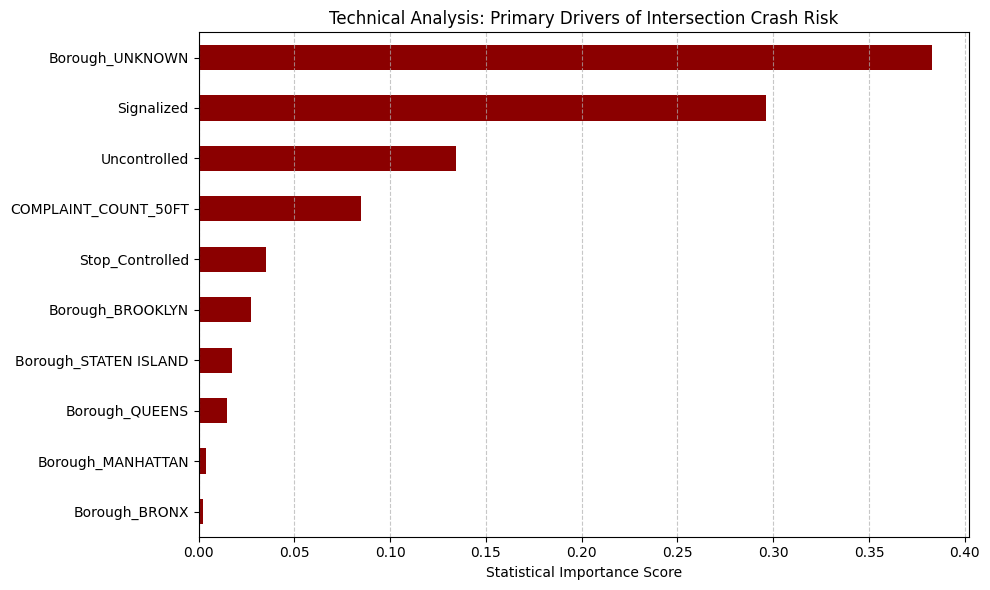

Final Model Training Complete.
Top 5 High-Risk Uncontrolled Intersections identified:

               INTERSECTION_ID BOROUGH  RISK_SCORE  COMPLAINT_COUNT_50FT
169   BRONX @ Unknown Location   BRONX    0.997908                    64
238   BRONX @ Unknown Location   BRONX    0.997908                    62
1939  BRONX @ Unknown Location   BRONX    0.997908                    72
759   BRONX @ Unknown Location   BRONX    0.997908                    61
329   BRONX @ Unknown Location   BRONX    0.997908                    81


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier

# 1. Initialize the model with the exact 'Best Parameters'
final_model = RandomForestClassifier(
    criterion='gini',
    max_depth=10,
    min_samples_split=10,
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

# 2. Train on the full training set
final_model.fit(X_train, y_train)

# 3. Generate Risk Scores for EVERY intersection in the original dataset
# Use X (the full feature set) to get a comprehensive city-wide profile
df['RISK_SCORE'] = final_model.predict_proba(X)[:, 1]

# 4. Filter for the "Uncontrolled" intersections we would want to suggest improvements for.
improvement_list = df[df['Uncontrolled'] == 1].copy()
improvement_list = improvement_list.sort_values(by='RISK_SCORE', ascending=False)

# 5. Export the Priority List to CSV for the final project submission
improvement_list.to_csv("PRIORITY_IMPROVEMENT_LIST.csv", index=False)

# 6. Visualize Feature Importance for the technical report
importances = final_model.feature_importances_
feat_importances = pd.Series(importances, index=X.columns).sort_values(ascending=True)

plt.figure(figsize=(10, 6))
feat_importances.plot(kind='barh', color='darkred')
plt.title('Technical Analysis: Primary Drivers of Intersection Crash Risk')
plt.xlabel('Statistical Importance Score')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("Final Model Training Complete.")
print(f"Top 5 High-Risk Uncontrolled Intersections identified:\n")
print(improvement_list[['INTERSECTION_ID', 'BOROUGH', 'RISK_SCORE', 'COMPLAINT_COUNT_50FT']].head())

## 7. Top 100 High-Risk Uncontrolled Intersections
This cell extracts the top 100 uncontrolled intersections ranked by risk score and displays a borough-wise distribution.

In [7]:
# Extract the top 100 uncontrolled intersections
top_100_list = df[df['Uncontrolled'] == 1].sort_values(by='RISK_SCORE', ascending=False).head(100)

# Display Summary
print("--- TOP 100 UNCONTROLLED INTERSECTIONS SUMMARY ---")
print(f"Borough Distribution:\n{top_100_list['BOROUGH'].value_counts()}")
print(f"\nAverage Complaint Count: {top_100_list['COMPLAINT_COUNT_50FT'].mean():.2f}")
print(f"Minimum Risk Score: {top_100_list['RISK_SCORE'].min():.4f}")

# Save the top 100 list
top_100_list.to_csv("TOP_100_PRIORITY_INTERSECTIONS.csv", index=False)

--- TOP 100 UNCONTROLLED INTERSECTIONS SUMMARY ---
Borough Distribution:
BOROUGH
BRONX            55
STATEN ISLAND    32
QUEENS           13
Name: count, dtype: int64

Average Complaint Count: 61.73
Minimum Risk Score: 0.9964


## 8. Final Project Summary and Recommendations

**Model Performance**
The final model finished with an **88% accuracy rate**. More importantly, the **Recall score of 0.97** shows that the model is extremely reliable at flagging intersections where crashes actually happen. For a safety project like this, having a high recall is the priority because it means we aren't missing many dangerous locations.

**Key Findings**
* **Primary Drivers:** According to the feature importance results, **Borough location** is the biggest predictor of risk. Intersections in the **Bronx** and **Staten Island** are statistically much more likely to be high-risk in this dataset.
* **The Role of Complaints:** **Citizen complaints** are a major secondary factor. The top 100 high-risk intersections we found have an average of over **61 complaints** each, which shows a clear link between what people are reporting and where crashes occur.
* **Geographic Focus:** The vast majority (87%) of the highest-risk "uncontrolled" intersections are concentrated in just two boroughs: the **Bronx** and **Staten Island**.

**Recommendations**
I recommend that the DOT prioritizes these 100 intersections for site visits. Since these spots currently have no stop signs or signals but show very high risk scores, adding traffic controls there would be an effective way to use data to improve city safety.